In [60]:
# Load and Understand the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.datasets import load_gbsg2

df = load_gbsg2()
print(df.head())
print(df.describe())
print(df.dtypes)
print(df.shape)
print(df.isnull().sum())

  horTh  age menostat  tsize tgrade  pnodes  progrec  estrec  time  cens
0    no   70     Post     21     II       3       48      66  1814     1
1   yes   56     Post     12     II       7       61      77  2018     1
2   yes   58     Post     35     II       9       52     271   712     1
3   yes   59     Post     17     II       4       60      29  1807     1
4    no   73     Post     35     II       1       26      65   772     1
              age       tsize      pnodes      progrec       estrec  \
count  686.000000  686.000000  686.000000   686.000000   686.000000   
mean    53.052478   29.329446    5.010204   109.995627    96.252187   
std     10.120739   14.296217    5.475483   202.331552   153.083963   
min     21.000000    3.000000    1.000000     0.000000     0.000000   
25%     46.000000   20.000000    1.000000     7.000000     8.000000   
50%     53.000000   25.000000    3.000000    32.500000    36.000000   
75%     61.000000   35.000000    7.000000   131.750000   114.0000

Missing Values:
 horTh       0
age         0
menostat    0
tsize       0
tgrade      0
pnodes      0
progrec     0
estrec      0
time        0
cens        0
dtype: int64


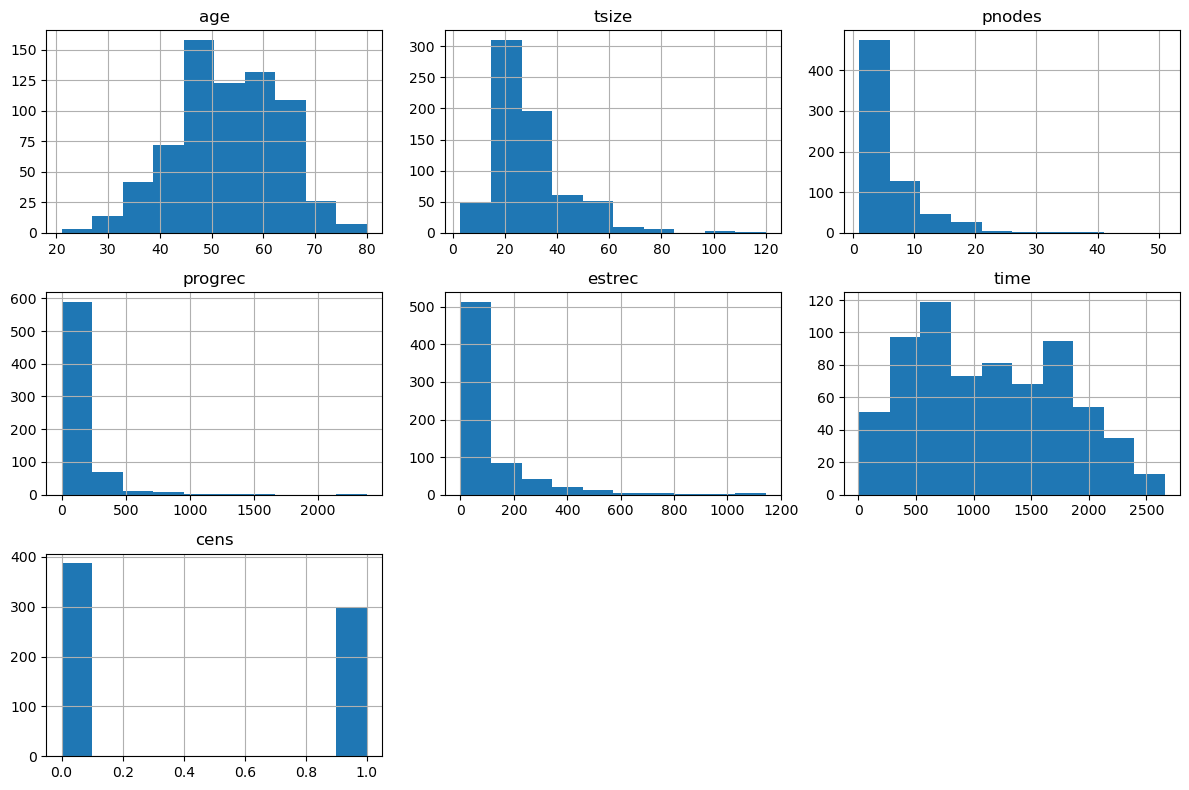

In [61]:
#Data Cleaning and distributions

missing = df.isnull().sum()
print("Missing Values:\n", missing)

#check data distributions
df.hist(figsize=(12,8))
plt.tight_layout()
plt.savefig("outputs\distributions.png")
plt.show()

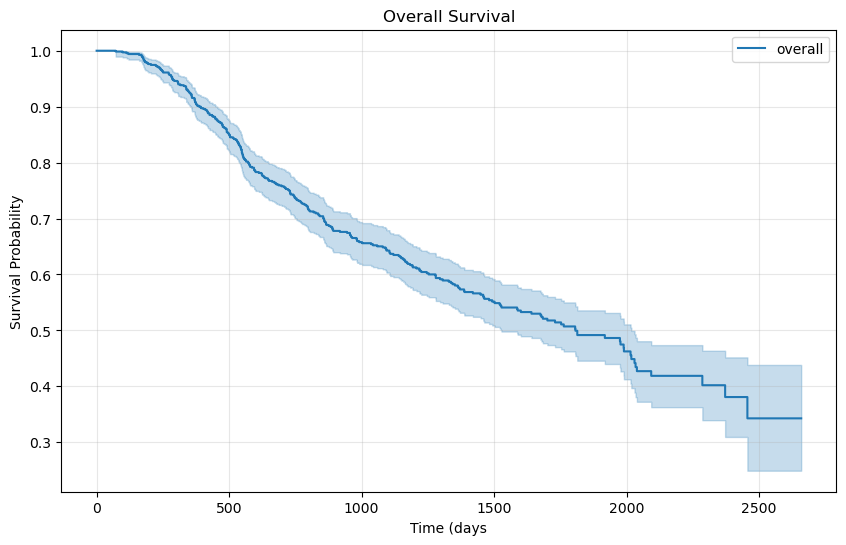

In [63]:
#Kaplan Meier curves

km = KaplanMeierFitter()
km.fit(df['time'], event_observed = df['cens'], label="overall")
plt.figure(figsize=(10,6))
km.plot_survival_function(ci_show =True)
plt.title("Overall Survival")
plt.xlabel("Time (days")
plt.ylabel("Survival Probability")
plt.grid(alpha=0.3)
plt.savefig("outputs\km_overall.png")
plt.show()


[0 1]
(686, 10)


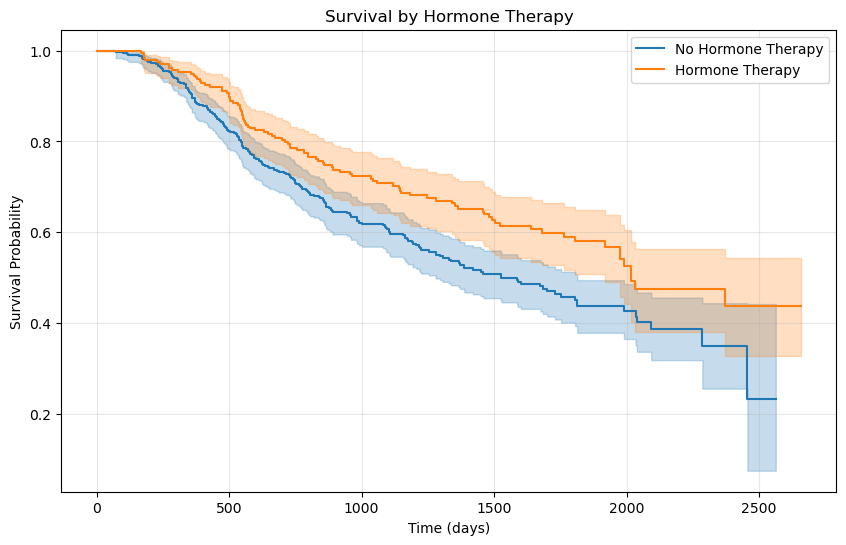

In [75]:
from lifelines.datasets import load_gbsg2
from lifelines.statistics import KaplanMeierFitter
import matplotlib.pyplot as plt
import os

df=load_gbsg2()
df['horTh'] = (df['horTh'] == 'yes').astype(int)

print(df['horTh'].unique())
print(df.shape)

os.makedirs("outputs", exist_ok =True)

fig, ax = plt.subplots(figsize=(10,6))
kmf = KaplanMeierFitter()

for group,label in[(0, "No Hormone Therapy") , (1, "Hormone Therapy")]:
    mask = df["horTh"] == group
    kmf.fit(df.loc[mask, 'time'],
        event_observed = df.loc[mask, 'cens'],
        label=label)
    kmf.plot_survival_function(ax=ax, ci_show =True)

plt.title("Survival by Hormone Therapy")
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.grid(alpha=0.3)
plt.savefig("outputs/km_by_treatment.png", dpi=150, bbox_inches ='tight')
plt.show()



In [ ]:
## Interpretation

#KM curves show that Hormone Therapy had consistently higher survival probability across all time points. The Curves diverge early around day 200 and 
#the separation is maintained throughout follow-up suggesting a sustained treatment effect

In [78]:
#Logrank Test

group0 = df[df['horTh'] == 0]
group1 = df[df['horTh'] == 1]

results = logrank_test(group0['time'], group1['time'],
                       event_observed0 = group0['cens'],
                       event_observed1= group1['cens'])

print(f"Log-rank test p-value: {results.p_value:.4f}")
print(f"Test statistic: {results.test_statistic: .4f}")


Log-rank test p-value: 0.0002
Test statistic:  13.7025


In [ ]:
#Interpretation- Log-rank test p-value: 0.0002 between two groups indicate that the difference is statistically significant

Dtypes:
 horTh       int64
age         int64
menostat    int64
tsize       int64
tgrade      int64
pnodes      int64
progrec     int64
estrec      int64
time        int64
cens        int64
dtype: object

NaN counts:
 horTh       0
age         0
menostat    0
tsize       0
tgrade      0
pnodes      0
progrec     0
estrec      0
time        0
cens        0
dtype: int64

Shape: (686, 10)


<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'cens'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1737.17
         time fit was run = 2026-03-10 00:47:53 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
horTh     -0.34      0.71      0.13           -0.59           -0.08                0.55                0.92
age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
menostat   0.27      1.31      0.18           -0.09            0.63                0.91                1.87
tsize      0.01      1.01      0.00           -0.00            0.02                1.00                1.02
tgrade     0.28      1.32      0.11            0.07            0.49                1.08                1.63
pnodes     0.05      1.05      0.01            0.04            0.06                1.04                1.07
progrec   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
estrec     0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to     z      p  -log2(p)
covariate                               
horTh        0.00 -2.61   0.01      6.81
age          0.00 -1.01   0.31      1.68
menostat     0.00  1.46   0.14      2.79
tsize        0.00  1.95   0.05      4.30
tgrade       0.00  2.64   0.01      6.93
pnodes       0.00  6.73 <0.005     35.82
progrec      0.00 -3.89 <0.005     13.26
estrec       0.00  0.37   0.71      0.50
---
Concordance = 0.69
Partial AIC = 3490.35
log-likelihood ratio test = 101.86 on 8 df
-log2(p) of ll-ratio test = 58.96

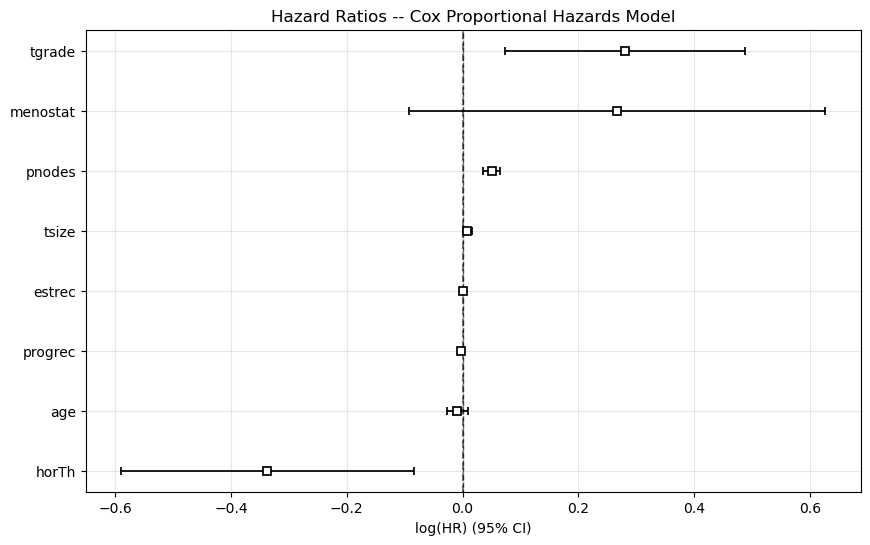

In [82]:
from lifelines.datasets import load_gbsg2
from lifelines import CoxPHFitter

import matplotlib.pyplot as plt
import pandas as pd
import os

df = load_gbsg2()

#conver all string columns to numeric
df['horTh'] = (df['horTh'] == 'yes').astype(int)
df['menostat'] =(df['menostat'] == 'Post').astype(int)
df['tgrade'] = df['tgrade'].map({'I': 1, 'II': 2, 'III' : 3})

print("Dtypes:\n" , df.dtypes)
print("\nNaN counts:\n", df.isnull().sum())
print("\nShape:", df.shape)

                
cox =CoxPHFitter()
cox.fit(df, duration_col ='time' , event_col ='cens')
cph.print_summary()

plt.figure(figsize=(10,6))
cph.plot()
plt.title('Hazard Ratios -- Cox Proportional Hazards Model')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.grid(alpha=0.3)
plt.savefig("outputs/cox_forest_plot.png", dpi=150, bbox_inches ='tight')
plt.show()
            





In [ ]:
#Interpreation- Cox model shows that Hormone Therapy remained as significant and independant predictor of survival with a hazard ratio of 0.70 
#which is a 30% reduction in the resk of recurrence or death.